# [LAB-02] 5. 계층적 군집 - 연습문제

## 준비작업

### 라이브러리 참조

In [8]:
from jussam import load_data
from helpers import *
from pandas import crosstab

## 📚 채널을 모르는 새 거래처를 어느 그룹에 넣을 것인가

### 당신은 식자재 도매 유통업체의 고객관리 담당자입니다.

거래처 440곳이 지난 1년 동안 신선식품·유제품·식료품·냉동식품·세제/종이류·즉석식품 여섯 항목에 각각 얼마를 썼는지가 정리되어 있습니다. 기존 거래처에는 호텔·레스토랑·카페(Horeca)인지 소매점(Retail)인지가 채널 정보로 적혀 있지만, 앞으로 들어올 새 거래처에는 그 정보 없이 주문 내역만 남습니다.

팀장은 "지출 패턴만으로 거래처를 묶어 담당자를 배정하자"고 합니다. 그런데 지난 단원에서 쓰던 KMeans와 이번에 배운 계층적 군집은 **같은 개수로 나눠도 결과가 같지 않다**고 합니다. 참고로 몇몇 큰 거래처의 지출액이 워낙 커서 그대로 거리를 재면 그 거래처들이 결과를 지배하므로, 값의 치우침을 줄여 놓고 시작해야 합니다.

두 방법이 같은 개수로 나눴을 때 결과가 얼마나 달라지는지 확인하고, 담당자 배정에 어느 쪽 결과를 쓸 것인지 판단하세요.

### 💻 코드 작성

#### 데이터 가져오기

In [9]:
origin = load_data("wholesale_customers")
origin.head()

📚 이 데이터 세트는 도매 유통업체의 고객 정보를 담고 있습니다. 다양한 제품 카테고리에 대한 연간 지출액(mu, 화폐 단위)을 포함합니다. (출처: https://www.kaggle.com/datasets/binovi/wholesale-customers-data-set)

컬럼명            의미                  설명
----------------  --------------------  --------------------------------------------------------------------------------------------
Channel           유통 채널             고객의 거래 채널을 나타냄. 주로 Horeca(호텔·레스토랑·카페) 또는 Retail(소매점) 구분에 사용됨
Region            지역                  고객이 속한 지리적 지역 구분 변수. 특정 국가 내의 권역 정보
Fresh             신선식품 구매액       육류, 채소, 과일 등 신선식품 카테고리에 대한 연간 구매 금액
Milk              유제품 구매액         우유, 치즈, 요거트 등 유제품 카테고리에 대한 연간 구매 금액
Grocery           식료품 구매액         가공식품, 일반 식료품 등 장기 보관 식품 카테고리 구매 금액
Frozen            냉동식품 구매액       냉동 육류, 냉동 가공식품 등 냉동식품 카테고리 구매 금액
Detergents_Paper  세제·종이류 구매액    세제, 화장지, 키친타월 등 생활 소모품 구매 금액
Delicassen        즉석·가공식품 구매액  즉석식품, 델리 식품, 가공 반찬류 등의 구매 금액



,Channel,Region,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
0,2,3,12669,9656,7561,214,2674,1338
1,2,3,7057,9810,9568,1762,3293,1776
2,2,3,6353,8808,7684,2405,3516,7844
3,1,3,13265,1196,4221,6404,507,1788
4,2,3,22615,5410,7198,3915,1777,5185


#### 전처리 (채널·지역 제외 / 지출액의 치우침 줄이기)

In [10]:
# 채널과 지역은 지출액이 아니라 거래처를 설명하는 정보이므로 거리 계산에서 뺀다
df1 = origin.drop(columns=["Channel", "Region"])

# 몇몇 큰 거래처 때문에 한쪽으로 심하게 치우친 금액을 완만하게 만든다
df2 = my_prep.log_transform(df1, log_columns=list(df1.columns), verbose=False)

print(f"군집분석에 사용할 변수 개수: {df2.shape[1]}개")

df2.head()

군집분석에 사용할 변수 개수: 6개


,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
0,9.447,9.175,8.931,5.366,7.891,7.199
1,8.862,9.191,9.166,7.474,8.100,7.482
2,8.757,9.083,8.947,7.785,8.165,8.968
3,9.493,7.087,8.348,8.765,6.229,7.489
4,10.026,8.596,8.882,8.273,7.483,8.554


#### 무리 개수 정하기

In [11]:
final_k, k_df = my_cluster.best_k(df2, plot=False)
k_df

StandardScaler 적용 (6개 컬럼)
컬럼                            변환 전                  변환 후
--------------------------------------------------------
Fresh               1.10 ~ 11.63          -5.16 ~ 1.96
Milk                4.01 ~ 11.21          -3.81 ~ 2.86
Grocery             1.10 ~ 11.44          -6.59 ~ 2.69
Frozen              3.22 ~ 11.02          -3.18 ~ 2.90
Detergents_Paper        1.10 ~ 10.62          -3.31 ~ 2.23
Delicassen          1.10 ~ 10.78          -4.25 ~ 3.14
[1단계] 엘보우 포인트   : k = 5  (뭉침만 확인 → 후보)
[2단계] 실루엣 균형지수 : k = 2  (뭉침 + 분리 + 크기 균형)
------------------------------------------------------------
두 지표가 다른 k를 가리킵니다.
  · k = 5 : 균형지수 0.0281 (스코어 0.1909, 두께비 1.8519)
  · k = 2 : 균형지수 0.1682 (스코어 0.2896, 두께비 1.328)
------------------------------------------------------------
>>> 최종 선택: k = 2
    (지표는 후보를 좁혀줄 뿐이므로, 목적과 도메인 지식으로 한 번 더 확인할 것)


,k,이너셔,감소량,스코어,전체면적,두께비,최소상대면적,균형지수
0,2,1847.995,NaN,0.290,127.418,1.328,0.771,0.168
1,3,1558.090,289.905,0.259,113.770,2.642,0.244,0.024
2,4,1392.488,165.601,0.187,82.232,2.062,0.208,0.019
3,5,1271.310,121.179,0.191,83.994,1.852,0.273,0.028
4,6,1178.638,92.671,0.192,84.525,5.833,0.046,0.002
5,7,1100.517,78.121,0.187,82.205,4.200,0.176,0.008
6,8,1038.942,61.575,0.171,75.407,5.941,0.113,0.003
7,9,987.746,51.196,0.179,78.715,5.529,-0.019,-0.001
8,10,936.833,50.913,0.175,77.005,7.583,0.125,0.003


#### 거리 기준으로 계층적 군집 (덴드로그램)

StandardScaler 적용 (6개 컬럼)
컬럼                            변환 전                  변환 후
--------------------------------------------------------
Fresh               1.10 ~ 11.63          -5.16 ~ 1.96
Milk                4.01 ~ 11.21          -3.81 ~ 2.86
Grocery             1.10 ~ 11.44          -6.59 ~ 2.69
Frozen              3.22 ~ 11.02          -3.18 ~ 2.90
Detergents_Paper        1.10 ~ 10.62          -3.31 ~ 2.23
Delicassen          1.10 ~ 10.78          -4.25 ~ 3.14
[계층적 군집] 군집 수 = 4, 연결 방법 = ward, 거리 = euclidean
  · 자른 높이(병합 거리) = 15.0000
  · 군집별 데이터 개수 : 0번 90개, 1번 187개, 2번 116개, 3번 47개


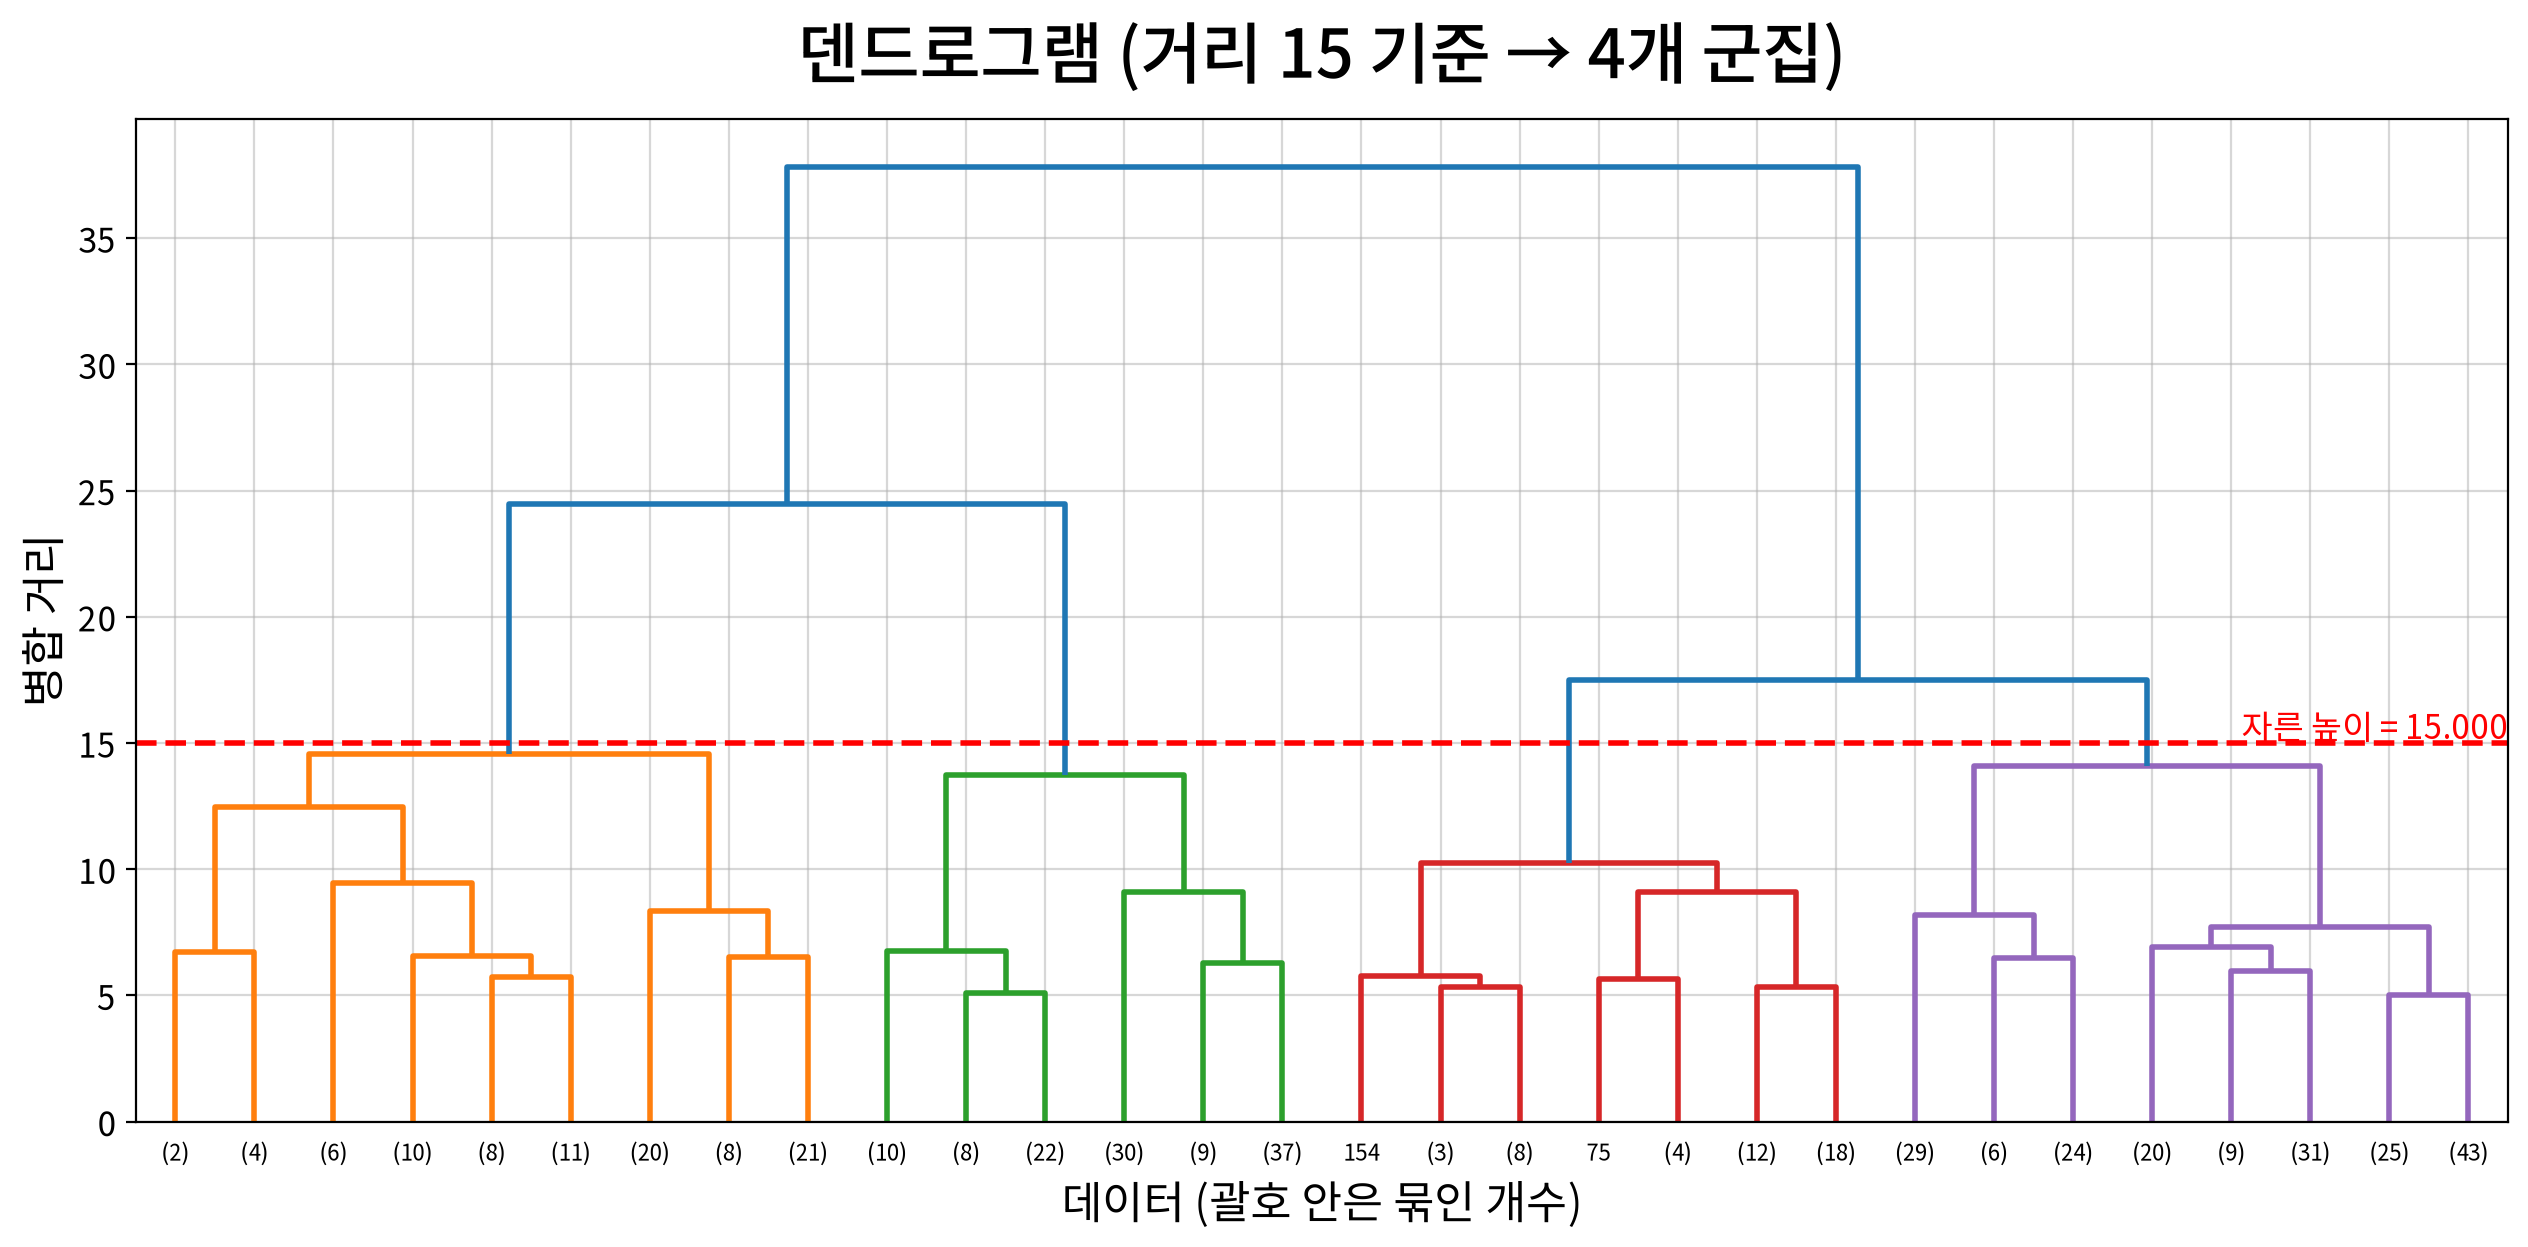

In [12]:
estimator_d, df_d = my_cluster.agglomerative(df2, distance_threshold=15)

#### 같은 개수로 두 방법을 각각 수행하고 맞대어 보기

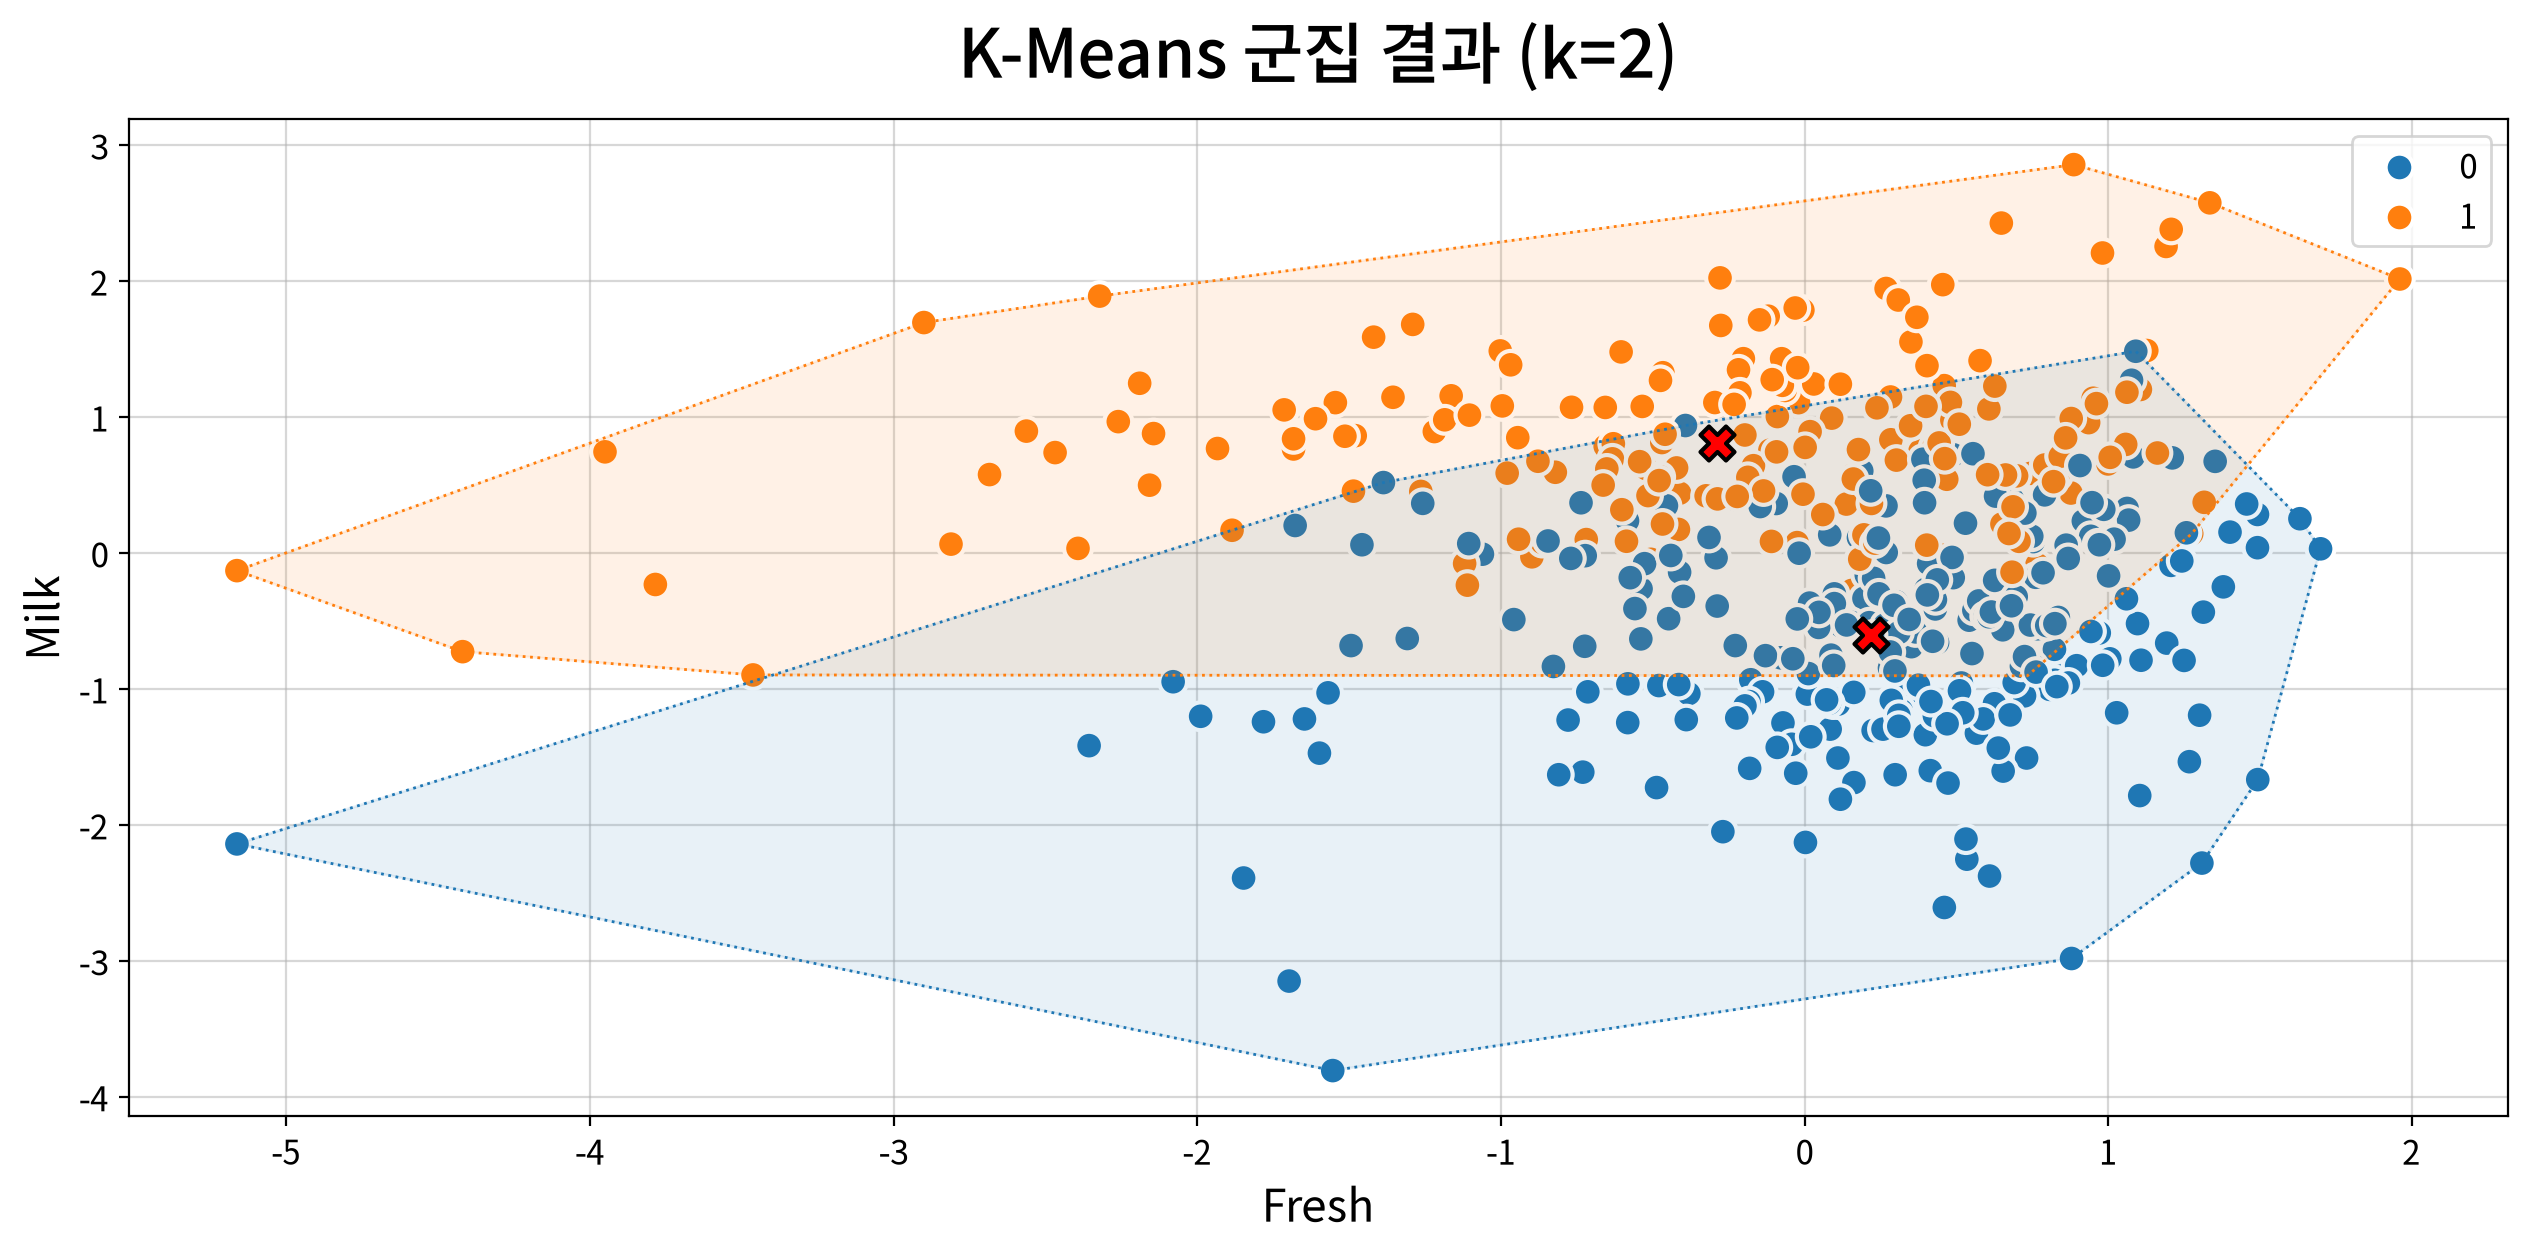

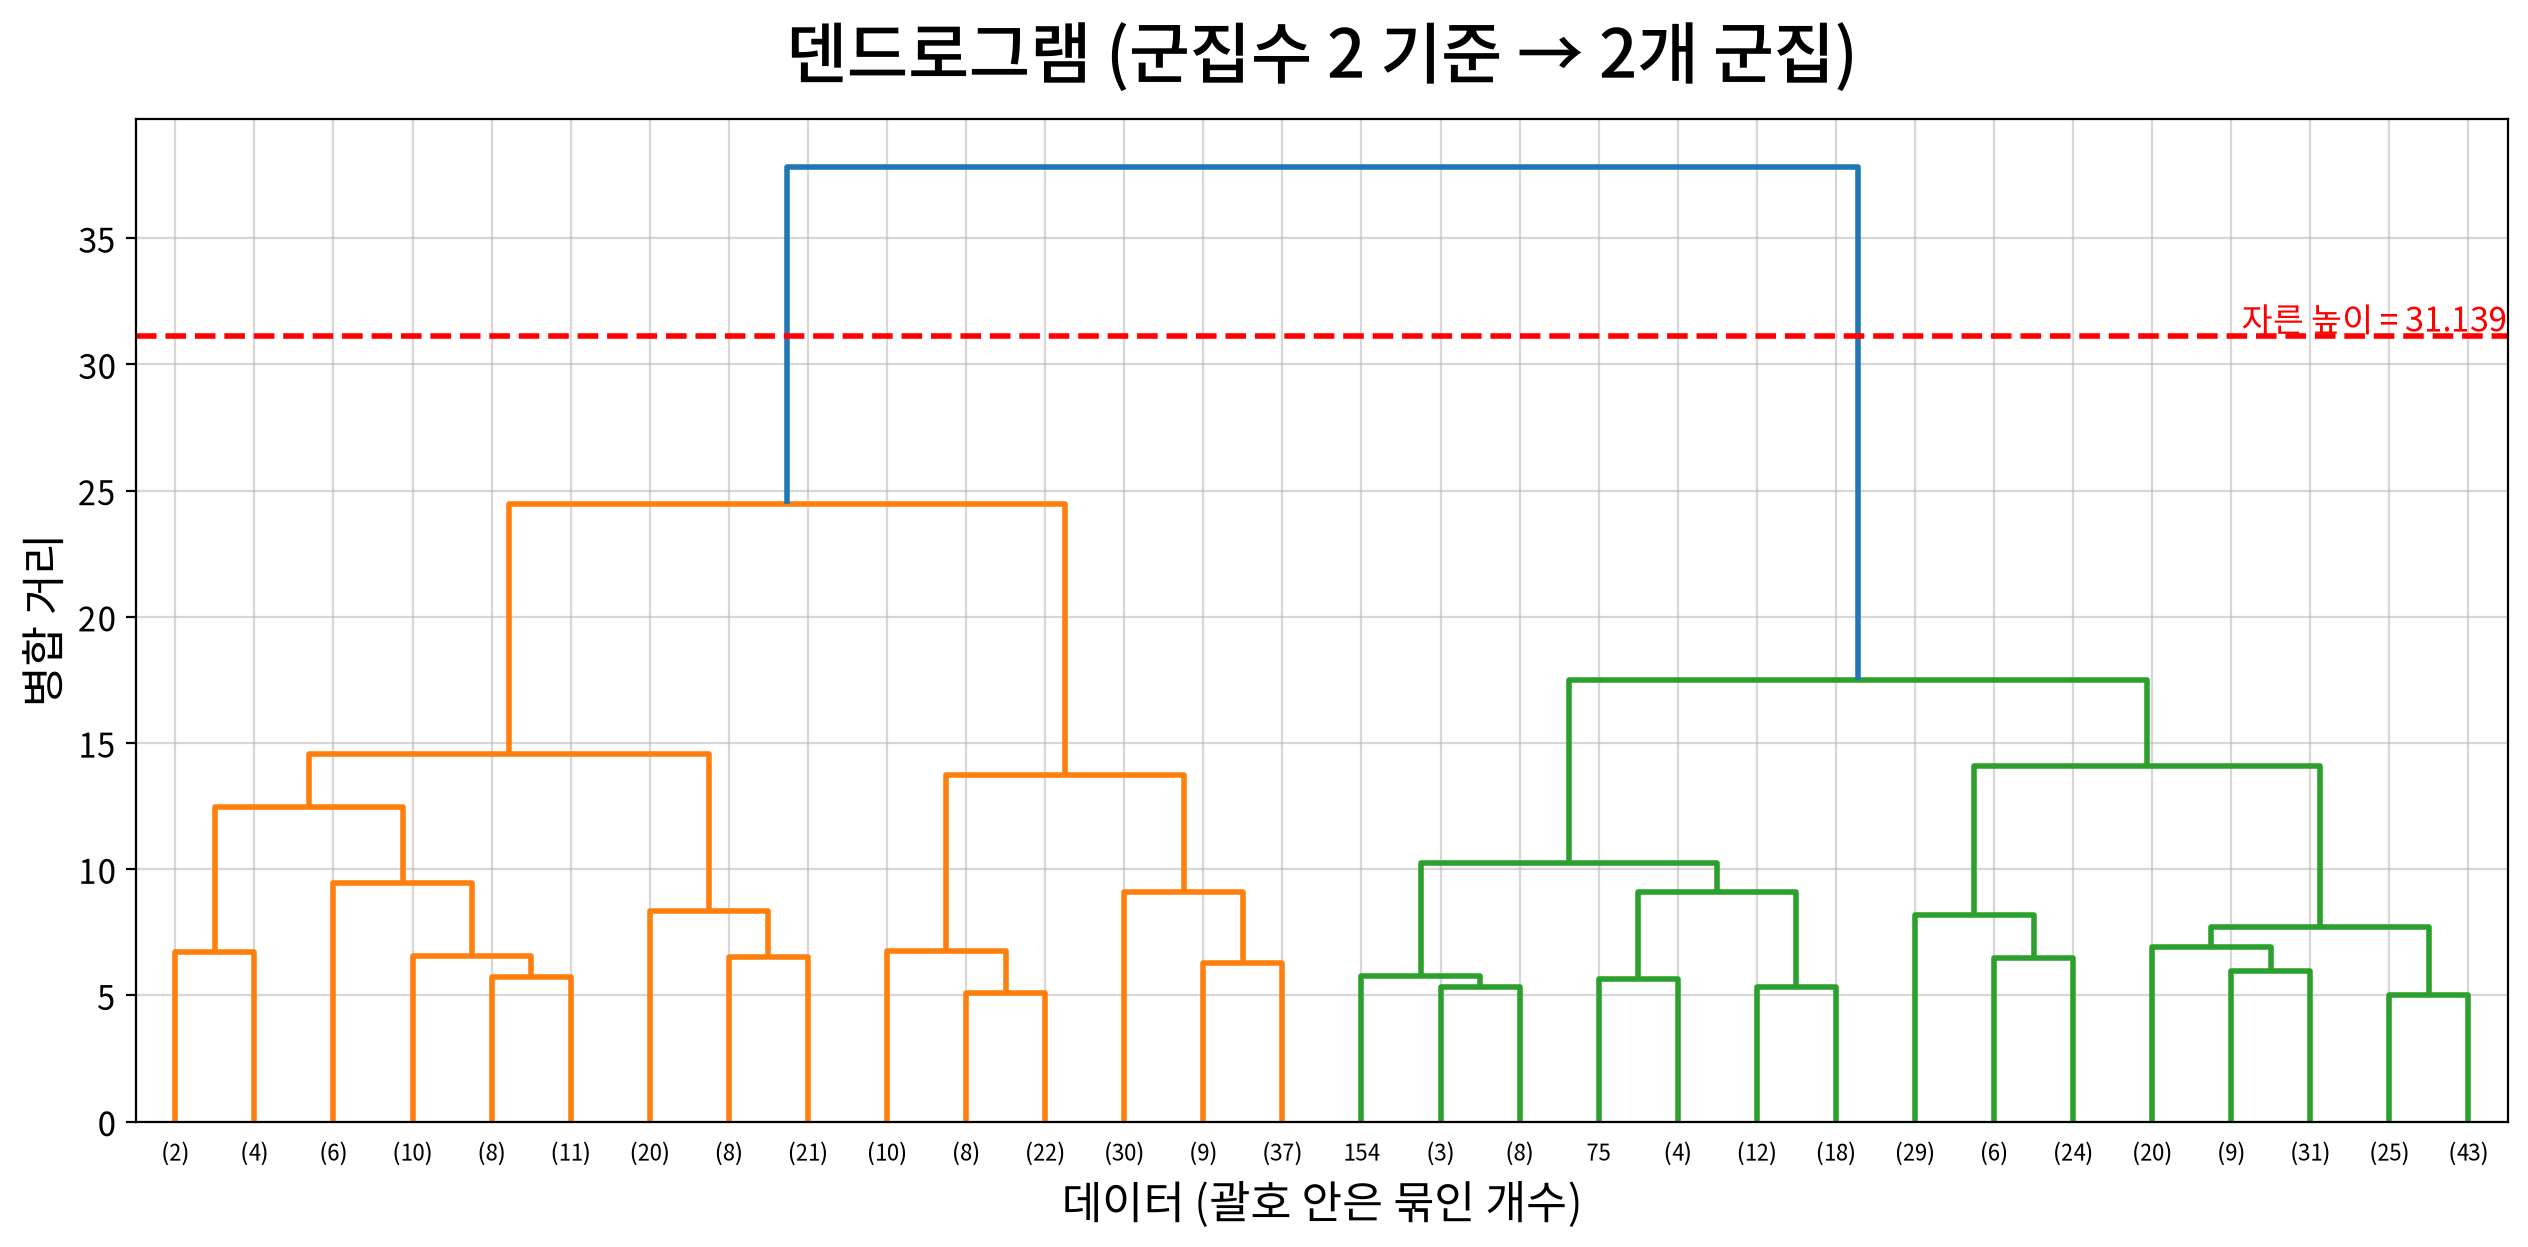


[무리별 거래처 수]
KMeans : {0: 251, 1: 189}
계층적 : {0: 206, 1: 234}

[KMeans(행) × 계층적(열)]
그룹번호    0    1
그룹번호          
0      31  220
1     175   14

두 방법이 서로 다른 무리에 넣은 거래처: 45곳


In [13]:
estimator_k, df_k, center_df = my_cluster.kmeans(df2, k=final_k, verbose=False)
estimator_h, df_h = my_cluster.agglomerative(df2, k=final_k, verbose=False)

print("\n[무리별 거래처 수]")
print("KMeans :", df_k["그룹번호"].value_counts().sort_index().to_dict())
print("계층적 :", df_h["그룹번호"].value_counts().sort_index().to_dict())

ct = crosstab(df_k["그룹번호"], df_h["그룹번호"])
print("\n[KMeans(행) × 계층적(열)]")
print(ct.to_string())

# 가장 많이 겹치는 무리끼리 짝지었을 때 그 짝에서 어긋난 거래처
print(f"\n두 방법이 서로 다른 무리에 넣은 거래처: {ct.iloc[0, 0] + ct.iloc[1, 1]}곳")

#### 기존 거래처의 실제 채널과 대조

In [14]:
ct_k = crosstab(df_k["그룹번호"], origin["Channel"])
ct_h = crosstab(df_h["그룹번호"], origin["Channel"])

print("[KMeans × 실제 채널]")
print(ct_k.to_string())
print("\n[계층적 × 실제 채널]")
print(ct_h.to_string())

print(f"\nKMeans 일치 거래처 : {ct_k.max(axis=1).sum()}곳")
print(f"계층적 일치 거래처 : {ct_h.max(axis=1).sum()}곳")

[KMeans × 실제 채널]
Channel    1    2
그룹번호             
0        244    7
1         54  135

[계층적 × 실제 채널]
Channel    1    2
그룹번호             
0         71  135
1        227    7

KMeans 일치 거래처 : 379곳
계층적 일치 거래처 : 362곳


### 문제 풀이

#### 1. 무리 개수를 2개부터 10개까지 바꿔 가며 확인해 보면, 뭉침만 보는 지표가 가리키는 개수와 뭉침·분리·크기 균형까지 함께 보는 지표가 가리키는 개수가 서로 다릅니다. 최종적으로 채택되는 개수는 몇 개인가요? (개)

- **정답**: `2`
- **복습 개념**: 최적 무리 개수를 정하는 두 지표의 역할 분담입니다. 뭉침의 정도(이너셔)가 꺾이는 지점은 후보를 좁혀 줄 뿐이고, 뭉침·분리·크기 균형을 모두 반영한 값이 최종 근거가 됩니다. 계층적 군집도 결국 "몇 개로 나눌까"를 정해야 하므로, 지난 단원의 이 절차를 그대로 씁니다.
- **풀이 접근**: 2개부터 10개까지 나눠 보며 무리 안이 얼마나 촘촘한지, 옆 무리와 얼마나 떨어져 있는지, 무리 크기가 고른지를 개수별로 모읍니다. 그다음 세 가지를 함께 반영한 값이 가장 큰 행의 개수를 읽습니다.
- **근거(계산 결과)**: 뭉침만 보는 지표는 5개를 가리키지만, 세 가지를 함께 본 값은 2개일 때 0.168로 가장 크고 5개일 때는 0.028에 그칩니다. 출력의 `[1단계] 엘보우 포인트 : k = 5`, `[2단계] 실루엣 균형지수 : k = 2`, `>>> 최종 선택: k = 2`로 확인됩니다.
- **헷갈리기 쉬운 점**: 먼저 계산된 5를 답으로 적기 쉽습니다. 뭉침의 정도는 각 무리가 자기 중심 가까이 모여 있는지만 볼 뿐, 옆 무리와 떨어져 있는지도 무리 크기가 한쪽으로 쏠렸는지도 보지 않습니다. 출력이 굳이 5를 "후보"라고 적어 둔 이유가 여기에 있습니다.

#### 2. 이번에는 개수를 정해 주지 않고, 가까운 거래처끼리 차례로 붙여 나가되 병합 거리가 15를 넘으면 더 이상 합치지 않도록 했습니다. 거래처는 몇 개의 무리로 나뉘나요? (개)

- **정답**: `4`
- **복습 개념**: 계층적 군집에서 나무를 자르는 두 가지 방법 중 "거리 기준"입니다. 개수를 사람이 정해 넣는 대신 "이만큼 멀면 남남으로 둔다"는 기준만 주면, 무리의 개수는 데이터가 정합니다. KMeans에는 없는 방식입니다.
- **풀이 접근**: 합칠 수 있는 최대 거리를 15로 두고 계층적 군집을 수행한 뒤, 만들어진 무리의 개수를 확인합니다. 덴드로그램에서 높이 15에 가로선을 긋고 그 선과 만나는 가지의 수를 세는 것과 같은 이야기입니다.
- **근거(계산 결과)**: 출력의 `[계층적 군집] 군집 수 = 4`이며, 무리별 거래처 수는 187곳·116곳·90곳·47곳입니다. 덴드로그램에도 자른 높이 15가 빨간 점선으로 그려지고, 그 선과 만나는 가지가 정확히 **4개**입니다.
- **함께 생각해 볼 점**: 기준을 20으로 올리면 3개, 10으로 내리면 9개가 됩니다. 거리 기준은 개수를 대신 정해 주는 것이 아니라 "얼마나 비슷해야 같은 무리로 볼 것인가"를 정하는 일입니다. 담당자를 4명 둘 수 있는지 9명 둘 수 있는지는 지표가 아니라 조직 사정이 정합니다.

#### 3. 앞에서 채택한 개수로 두 방법을 각각 돌린 뒤 두 결과를 맞대어, 가장 많이 겹치는 무리끼리 짝지었습니다. 그 짝에서 어긋난 — 즉 두 방법이 서로 다른 무리에 넣은 — 거래처는 모두 몇 곳인가요? (곳)

- **정답**: `45`
- **복습 개념**: 같은 개수로 나눠도 방법이 다르면 결과가 달라진다는 사실을 숫자로 확인하는 단계입니다. 두 결과를 비교할 때는 교차표를 만들되, 무리 번호 자체는 아무 의미가 없어 0번과 0번이 같은 무리라는 보장이 없다는 점에 주의해야 합니다.
- **풀이 접근**: 두 방법의 무리 번호로 교차표를 만들면 2×2 표가 나옵니다. 값이 큰 칸 두 개가 서로 대응하는 짝이고, 나머지 두 칸이 두 방법의 판단이 갈린 거래처입니다. 그 두 칸을 더합니다.
- **근거(계산 결과)**: 교차표는 KMeans 0번 무리가 계층적 1번과 220곳, KMeans 1번이 계층적 0번과 175곳 겹칩니다. 짝에서 벗어난 칸은 31곳과 14곳이므로 31 + 14 = **45곳**입니다. 출력의 `두 방법이 서로 다른 무리에 넣은 거래처: 45곳`으로 확인됩니다.
- **자주 하는 실수**: 번호가 같은 칸(0-0과 1-1)을 일치로 보고 31 + 14를 "맞은 개수"로 세면 정반대의 답이 나옵니다. 군집분석의 무리 번호는 이름표일 뿐 순서도 의미도 없습니다. 두 결과를 비교할 때는 항상 겹치는 양이 가장 큰 칸끼리 짝을 지어 놓고 시작하세요.

#### 4. 같은 개수로 나눈 두 결과 중, 두 무리의 크기가 더 고르게 나뉜 쪽에서 작은 쪽 무리에 속한 거래처는 몇 곳인가요? (곳)

- **정답**: `206`
- **복습 개념**: 두 방법이 무리를 만드는 원리의 차이가 크기에서 드러나는 지점입니다. KMeans는 중심점을 정해 놓고 가까운 쪽으로 배정하기를 반복하고, 계층적 군집(ward 연결)은 합쳤을 때 흩어짐이 가장 적게 늘어나는 쌍부터 붙여 나갑니다. 후자는 큰 덩어리에 계속 붙이는 것을 손해로 계산하므로 크기가 비교적 고르게 갈립니다.
- **풀이 접근**: 두 방법의 결과에서 각각 무리별 거래처 수를 세어 두 무리의 차이가 작은 쪽을 고르고, 그쪽의 작은 무리 크기를 읽습니다.
- **근거(계산 결과)**: KMeans는 251곳과 189곳(차이 62곳), 계층적은 234곳과 206곳(차이 28곳)으로 나뉩니다. 더 고르게 나뉜 쪽은 계층적이며 작은 무리는 **206곳**입니다. 출력의 `계층적 : {0: 206, 1: 234}`로 확인됩니다.
- **실무 포인트**: 담당자를 두 명 두고 거래처를 나눠 맡긴다면 234 대 206이 251 대 189보다 업무량이 고릅니다. 다만 크기가 고른 것과 잘 나뉜 것은 다른 이야기이므로, 균형만 보고 방법을 고르지는 마세요. 바로 다음 문제에서 이 둘이 갈립니다.

#### 5. 두 결과를 기존 거래처에 이미 적혀 있는 실제 채널(호텔·레스토랑·카페 / 소매점)과 각각 맞춰 보면, 실제 채널 구분과 일치하는 거래처가 더 많은 쪽은 어느 방법인가요?

- **정답**: `KMeans`
- **복습 개념**: 군집 결과를 이미 알고 있는 라벨과 대조해 해석하는 마지막 단계입니다. 군집분석은 정답을 모르고 수행하지만, 정답이 남아 있는 데이터라면 사후에 맞춰 보며 "이 무리가 무엇인가"를 읽고 방법을 고를 수 있습니다.
- **풀이 접근**: 각 방법의 무리 번호와 분석에서 빼 두었던 채널 정보로 교차표를 만들고, 무리마다 가장 많이 몰린 채널의 거래처 수를 더해 두 방법을 비교합니다.
- **근거(계산 결과)**: KMeans는 한 무리가 Horeca 244곳, 다른 무리가 Retail 135곳으로 합계 **379곳**이 일치합니다. 계층적은 227곳 + 135곳으로 362곳입니다. 출력의 `KMeans 일치 거래처 : 379곳`, `계층적 일치 거래처 : 362곳`으로 확인됩니다.
- **결론**: 당신이 팀장에게 보고할 내용은 "계층적 군집이 더 좋다"가 아닙니다. 같은 2개로 나눴는데도 45곳의 소속이 갈렸고, 계층적은 크기를 고르게 나눈 대신 실제 채널과는 17곳 덜 맞았습니다. 새 거래처의 채널을 지출 패턴으로 추정하는 것이 목적이라면 채널을 더 잘 복원한 KMeans 결과를, 담당자 업무량을 고르게 배분하는 것이 목적이라면 계층적 결과를 씁니다. 무엇보다 계층적 군집은 개수를 미리 정하지 않고 덴드로그램에서 자를 높이를 바꿔 가며 4개·9개로도 볼 수 있으므로, 팀 규모가 정해지지 않은 지금 단계에서는 이 그림을 함께 들고 가는 편이 낫습니다.